# Titanic Survival Analysis and Prediction

## 1. Importing Libraries

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

In [100]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Initial Data Exploration

The dataset structure and missing values were examined.

In [101]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [102]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [103]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [104]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

- Age contains missing values
- Cabin has many missing values
- Embarked contains a few missing values

## 4. Data Cleaning

New feature called `Deck` was extracted from the first letter of the cabin identifier. This feature may provide useful information for future analyses.

In [105]:
train['Deck'] = train['Cabin'].str[0]
test['Deck'] = test['Cabin'].str[0]

The `Cabin` variable was removed because it contained a large proportion of missing values.

In [106]:
train = train.drop('Cabin', axis=1)
test = test.drop('Cabin', axis=1)

Missing values in the `Age` variable were filled using the median because it handles extreme values better.

In [107]:
median_age = train['Age'].median()

train['Age'] = train['Age'].fillna(median_age)
test['Age'] = test['Age'].fillna(median_age)

Missing values in the `Embarked` variable were imputed using the mode because it is a categorical variable.

In [108]:
train['Embarked'] = train["Embarked"].fillna(train["Embarked"].mode()[0])

Outliers in the `Age` variable were retained because they represent valid passenger ages.


Missing value in the `Fare` variable was imputed.

In [109]:
test['Fare'] = test['Fare'].fillna(train['Fare'].median())

In [110]:
Q1 = train['Age'].quantile(0.25)
Q3 = train['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = train[(train['Age']<lower) | (train['Age']>upper)]
outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,S,NaN
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.00,0,0,113783,26.5500,S,C
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.00,0,0,248706,16.0000,S,NaN
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,Q,NaN
33,34,0,2,"Wheadon, Mr. Edward H",male,66.00,0,0,C.A. 24579,10.5000,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
827,828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,C,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.00,0,0,113572,80.0000,S,B
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,S,NaN
851,852,0,3,"Svensson, Mr. Johan",male,74.00,0,0,347060,7.7750,S,NaN


Missing value check after cleaning:

In [111]:
train.isnull().sum().drop('Deck')

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Since `Deck` was derived from `Cabin`, it inherits the missing values of the original variable. Therefore, it was excluded from the missing value summary after data cleaning.

In [112]:
test.isnull().sum().drop('Deck')

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Feature Engineering
New variables were created to better capture survival-related patterns.

### `Deck` Feature
This feature represents the passenger's deck location on the ship.

In [113]:
train['Deck'].head()

0    NaN
1      C
2    NaN
3      C
4    NaN
Name: Deck, dtype: object

### `Title` Feature 
Created a new feature based on passenger titles extracted from names.

In [114]:
train["Title"] = (
    train["Name"]
    .str.split(",")
    .str[1]
    .str.split(".")
    .str[0]
    .str.strip()
)

test["Title"] = (
    test["Name"]
    .str.split(",")
    .str[1]
    .str.split(".")
    .str[0]
    .str.strip()
)

train["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

### `Title_Grouped` Feature 
Rare titles were grouped into a single category to simplify the analysis.

In [115]:
rare_titles = [
    'Capt', 'Col', 'Don', 'Dr', 'Jonkheer',
    'Lady', 'Major', 'Mlle', 'Mme',
    'Ms', 'Rev', 'Sir', 'the Countess'
]

train['Title_Grouped'] = train['Title'].replace(rare_titles, 'Rare')
test['Title_Grouped'] = test['Title'].replace(rare_titles, 'Rare')

train['Title_Grouped'].value_counts()

Title_Grouped
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

#### `Age_Group` Feature
Passengers were grouped by age ranges.

In [116]:
max_age = int(train['Age'].max())

train['Age_Group'] = pd.cut(train['Age'], bins=[0,12,18,30,50,max_age], labels=['[0-12]', '(12-18]', '(18-30]', '(30-50]', f'(50-{max_age}]'], include_lowest=True)
test['Age_Group'] = pd.cut(test['Age'], bins=[0,12,18,30,50,max_age], labels=['[0-12]', '(12-18]', '(18-30]', '(30-50]', f'(50-{max_age}]'], include_lowest=True
)

train.groupby('Age_Group', observed=True)['Survived'].mean()

Age_Group
[0-12]     0.579710
(12-18]    0.428571
(18-30]    0.331096
(30-50]    0.423237
(50-80]    0.343750
Name: Survived, dtype: float64

#### `FamilySize` Feature
A new feature was created to represent the total family size aboard the ship.

In [117]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

#### `IsAlone` Feature
Passengers traveling alone were identified.

In [118]:
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

Check the new features:

In [119]:
train[["Age", "Age_Group", "FamilySize", "IsAlone"]].head()

,Age,Age_Group,FamilySize,IsAlone
0,22.0,(18-30],2,0
1,38.0,(30-50],2,0
2,26.0,(18-30],1,1
3,35.0,(30-50],2,0
4,35.0,(30-50],1,1


In [120]:
train[["Age", "Age_Group", "FamilySize", "IsAlone"]].describe()

,Age,FamilySize,IsAlone
count,891.000000,891.000000,891.000000
mean,29.361582,1.904602,0.602694
std,13.019697,1.613459,0.489615
min,0.420000,1.000000,0.000000
25%,22.000000,1.000000,0.000000
50%,28.000000,1.000000,1.000000
75%,35.000000,2.000000,1.000000
max,80.000000,11.000000,1.000000


## 6. Exploratory Data Analysis (EDA)

### Survival Rate by Gender

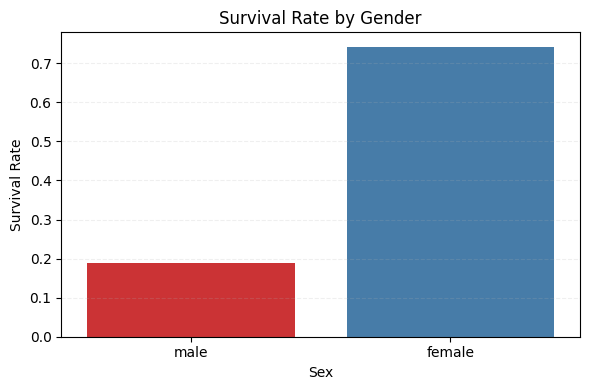

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

In [121]:
plt.figure(figsize=(6,4))

sns.barplot(data=train, x='Sex', y='Survived', hue='Sex', palette='Set1', errorbar=None)

plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')

plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

(train.groupby('Sex')['Survived'].mean() * 100).round(2)

Female passengers had a significantly higher survival rate than males. Approximately 74% of female passengers survived, compared to only about 19% of male passengers, indicating that gender was strongly related to survival outcomes.

### Survival Rate by Title_Grouped

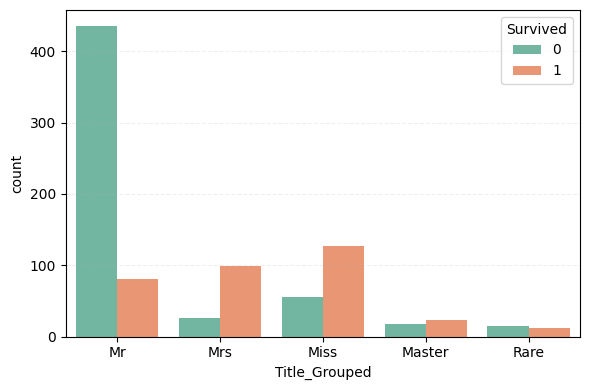

In [122]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x='Title_Grouped',
    hue='Survived',
    palette='Set2'
)

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Survival rates vary considerably across title groups. Passengers with the titles Mrs, Miss, and Master were more likely to survive, whereas passengers with the title Mr had a significantly lower survival rate.

### Survival by Passenger Class

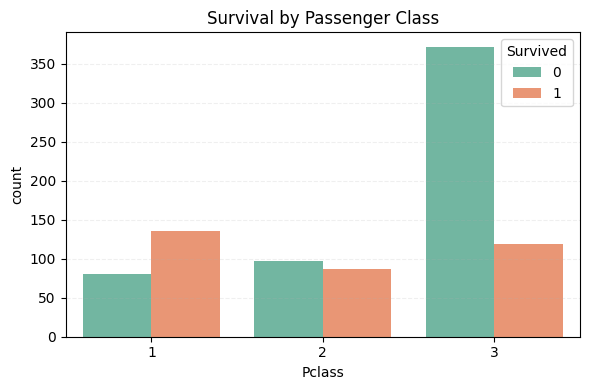

In [123]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Pclass', hue='Survived', palette='Set2')
plt.title('Survival by Passenger Class')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Passengers in higher classes were more likely to survive compared to those in lower classes.

### Survival Rate by Deck

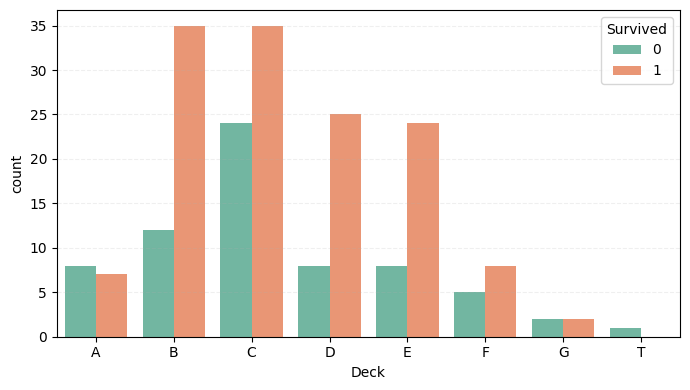

In [124]:
order = sorted(train["Deck"].dropna().unique())

plt.figure(figsize=(7,4))

sns.countplot(
    data=train,
    x='Deck',
    order=order,
    hue='Survived',
    palette='Set2'
)

plt.grid(axis="y", linestyle="--", alpha=0.2)
plt.tight_layout()

The Deck variable appears to be associated with survival. However, due to the high proportion of missing values in the Cabin column, the Deck variable also contains a substantial amount of missing data. Therefore, the reliability of the analysis based on this variable may be limited.

### Survival by Age Group

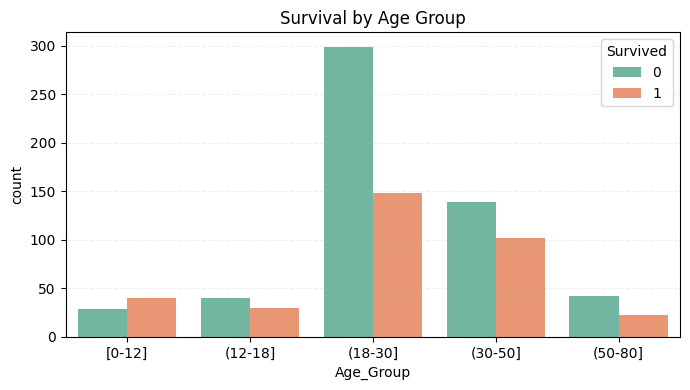

In [125]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=train,
    x='Age_Group',
    hue='Survived',
    palette='Set2'
)

plt.title('Survival by Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Survival rates vary across different age groups. The (18–30] age group is the largest group in the dataset and also has the highest number of deaths. In all age groups, the number of passengers who did not survive is higher than the number of survivors.

### Correlation Heatmap

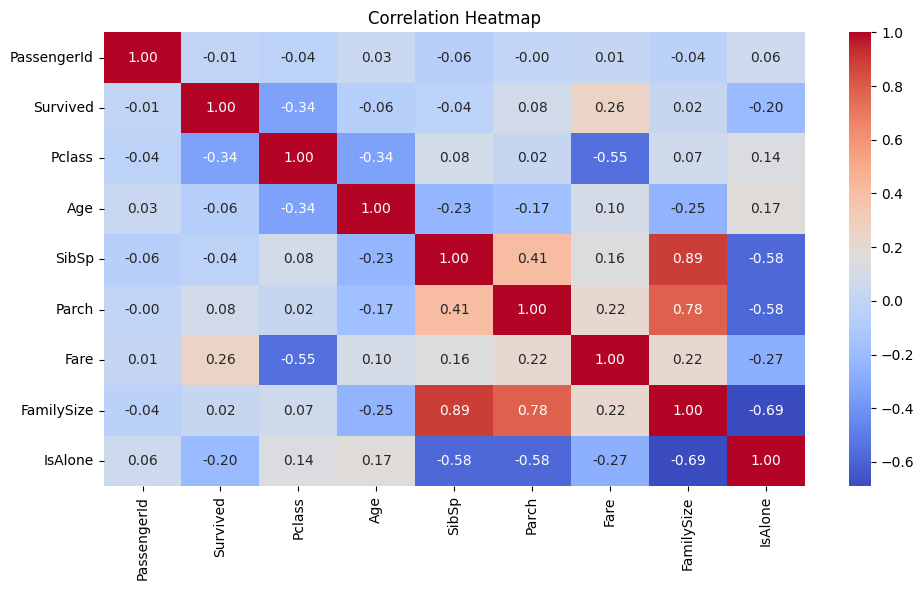

In [126]:
plt.figure(figsize=(10,6))

sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()

The heatmap indicates that `Pclass` has a moderate negative correlation with `Survived`, suggesting that passengers in higher classes were more likely to survive. `Fare` shows a weak positive relationship with `Survived`, while `IsAlone` has a weak negative correlation with survival outcomes.

### Fare by Survival

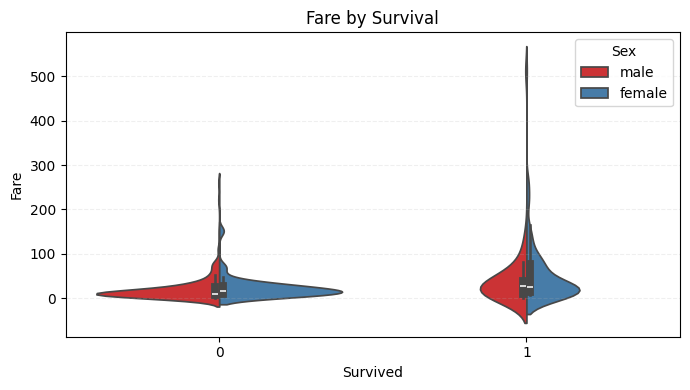

In [127]:
plt.figure(figsize=(7,4))

sns.violinplot(data=train, x='Survived', y='Fare', hue='Sex', split=True, palette='Set1')

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.title('Fare by Survival')
plt.tight_layout()

Passengers with higher fares were generally more likely to survive. Female passengers also appear to have better survival outcomes across different fare ranges.

### Survival Rate by IsAlone

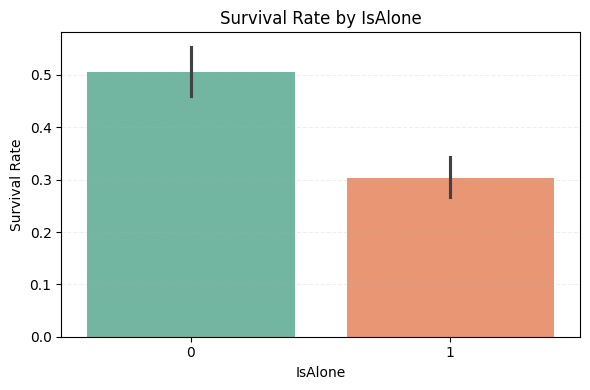

In [128]:
plt.figure(figsize=(6,4))

sns.barplot(data=train, x='IsAlone', y='Survived', hue='IsAlone', palette='Set2', legend=False)

plt.title('Survival Rate by IsAlone')
plt.ylabel('Survival Rate')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()

Passengers traveling alone appear to have lower survival rates compared to passengers traveling with family members.

### Family Size and Survival Rate

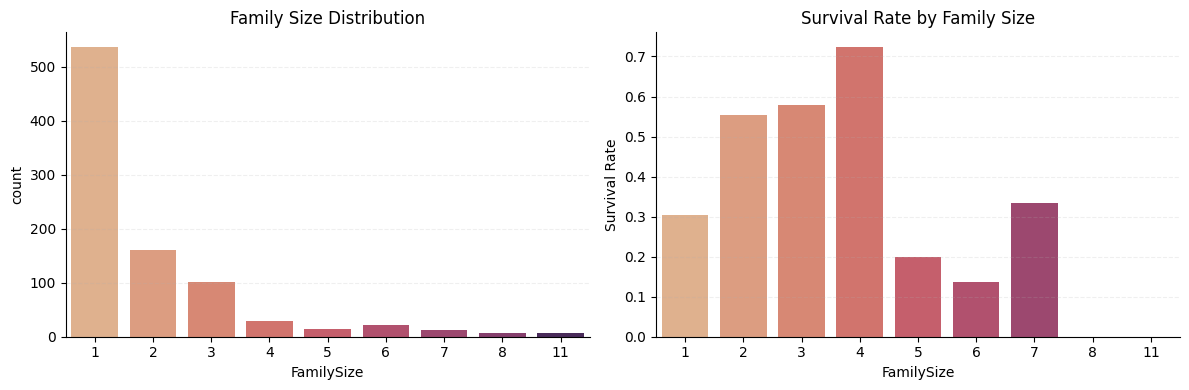

In [129]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(data=train, x='FamilySize', hue='FamilySize', palette='flare', legend=False, ax=ax[0])
ax[0].grid(axis='y', linestyle='--', alpha=0.2)
ax[0].set_title('Family Size Distribution')

sns.barplot(data=train, x='FamilySize', y='Survived', hue='FamilySize', palette='flare', legend=False, errorbar=None, ax=ax[1])
ax[1].grid(axis='y', linestyle='--', alpha=0.2)
ax[1].set_title('Survival Rate by Family Size')
ax[1].set_ylabel('Survival Rate')

sns.despine()
plt.tight_layout()

Most passengers traveled alone or with small families. Survival rates vary across different family sizes, with medium-sized families showing relatively higher survival rates compared to some larger family groups.

## 7. Machine Learning

In [130]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    891 non-null    int64   
 1   Survived       891 non-null    int64   
 2   Pclass         891 non-null    int64   
 3   Name           891 non-null    object  
 4   Sex            891 non-null    object  
 5   Age            891 non-null    float64 
 6   SibSp          891 non-null    int64   
 7   Parch          891 non-null    int64   
 8   Ticket         891 non-null    object  
 9   Fare           891 non-null    float64 
 10  Embarked       891 non-null    object  
 11  Deck           204 non-null    object  
 12  Title          891 non-null    object  
 13  Title_Grouped  891 non-null    object  
 14  Age_Group      891 non-null    category
 15  FamilySize     891 non-null    int64   
 16  IsAlone        891 non-null    int64   
dtypes: category(1), float64(2), int64(7

In [131]:
train.isna().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Deck             687
Title              0
Title_Grouped      0
Age_Group          0
FamilySize         0
IsAlone            0
dtype: int64

In [132]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    418 non-null    int64   
 1   Pclass         418 non-null    int64   
 2   Name           418 non-null    object  
 3   Sex            418 non-null    object  
 4   Age            418 non-null    float64 
 5   SibSp          418 non-null    int64   
 6   Parch          418 non-null    int64   
 7   Ticket         418 non-null    object  
 8   Fare           418 non-null    float64 
 9   Embarked       418 non-null    object  
 10  Deck           91 non-null     object  
 11  Title          418 non-null    object  
 12  Title_Grouped  418 non-null    object  
 13  Age_Group      418 non-null    category
 14  FamilySize     418 non-null    int64   
 15  IsAlone        418 non-null    int64   
dtypes: category(1), float64(2), int64(6), object(7)
memory usage: 49.7+ KB


In [133]:
test.isna().sum()

PassengerId        0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Deck             327
Title              0
Title_Grouped      0
Age_Group          0
FamilySize         0
IsAlone            0
dtype: int64

In [134]:
train['Deck'] = train['Deck'].fillna('Unknown')
test['Deck'] = test['Deck'].fillna('Unknown')

In [135]:
cat_cols = ['Sex', 'Embarked', 'Deck', 'Title_Grouped', 'Age_Group']

train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)

train, test = train.align(test, join='left', axis=1, fill_value=0)

In [136]:
train.isna().sum()

PassengerId           0
Survived              0
Pclass                0
Name                  0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
Title                 0
FamilySize            0
IsAlone               0
Sex_male              0
Embarked_Q            0
Embarked_S            0
Deck_B                0
Deck_C                0
Deck_D                0
Deck_E                0
Deck_F                0
Deck_G                0
Deck_T                0
Deck_Unknown          0
Title_Grouped_Miss    0
Title_Grouped_Mr      0
Title_Grouped_Mrs     0
Title_Grouped_Rare    0
Age_Group_(12-18]     0
Age_Group_(18-30]     0
Age_Group_(30-50]     0
Age_Group_(50-80]     0
dtype: int64

In [137]:
test.isna().sum()

PassengerId           0
Survived              0
Pclass                0
Name                  0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
Title                 0
FamilySize            0
IsAlone               0
Sex_male              0
Embarked_Q            0
Embarked_S            0
Deck_B                0
Deck_C                0
Deck_D                0
Deck_E                0
Deck_F                0
Deck_G                0
Deck_T                0
Deck_Unknown          0
Title_Grouped_Miss    0
Title_Grouped_Mr      0
Title_Grouped_Mrs     0
Title_Grouped_Rare    0
Age_Group_(12-18]     0
Age_Group_(18-30]     0
Age_Group_(30-50]     0
Age_Group_(50-80]     0
dtype: int64

In [138]:
train = train.drop(columns=['Name', 'Ticket', 'Title'])
test = test.drop(columns=['Name', 'Ticket', 'Title'])

In [139]:
X = train.drop('Survived', axis=1)
y = train['Survived']

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [142]:
from sklearn.ensemble import RandomForestClassifier

In [143]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [144]:
predictions = rf.predict(X_test)

In [145]:
from sklearn.metrics import classification_report

In [146]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       105
           1       0.82      0.80      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179



In [155]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print(scores)
print(scores.mean())

[0.78212291 0.80898876 0.85955056 0.80337079 0.85955056]
0.8227167158370474
